# Configuration

In [2]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List

In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [4]:
from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [5]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [6]:
from core.variables import *
from core.m_out_of_n_bootstrap import choose_best_m

# DGP

$$
\begin{aligned}
V(\tau) & = \max\{p\tau - c, 0\} \\
& = \max\{p\tau, c\} - c \\ 
& = p \max\{\tau, c / p\} - c
\end{aligned}
$$

Optimal targeting policy $\pi$: 
$$
\pi(P, p, c) = \begin{cases}
1, \quad \text{if } \theta(P) \geq c / p \\ 
0, \quad \text{o.w.}
\end{cases}
$$

## Visualization

In [14]:
def plot_value_function(
    price: float, cost: float, tau_lb: float, tau_ub: float, 
): 
    tau_arr = np.linspace(tau_lb, tau_ub, 1000)
    
    max_tau_arr = tau_arr.copy()
    max_tau_arr[tau_arr <= cost / price] = cost / price 

    V_arr = price * max_tau_arr - cost 
    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    # plot valuation function
    ax.plot(tau_arr, V_arr)

    # mark discontinuous point
    ax.plot(cost / price, 0, 'r*', markersize=20, label='Nondifferentiable Point')

    # plot attributes
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.set_title('Optimal Targeting Value Function', fontsize=title_size)
    ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
    ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
    ax.legend(loc='best', fontsize=legend_label_size)
    ax.grid()

    plt.tight_layout()
    plt.show()

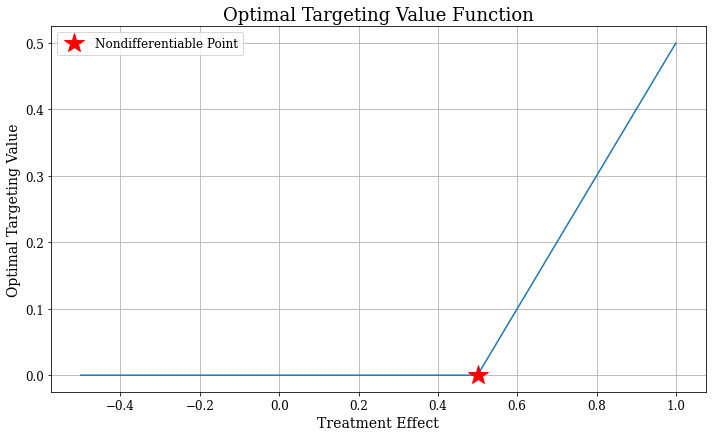

In [15]:
plot_value_function(price=1, cost=0.5, tau_lb=-0.5, tau_ub=1)

# Winner's Curse in Targeting

$$
\begin{aligned}
WC(\hat{\tau}) & = \max\{p\hat{\tau} - c, 0\} - (p\tau - c) \mathbb{I}\{\hat{\tau} \geq c / p\} \\
& = p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\} \\ 
& = \begin{cases}
p (\hat{\tau} - \tau), \quad & \text{if } \hat{\tau} > c / p \\ 
0, \quad & \text{if } \hat{\tau} = c / p \\ 
0, \quad & \text{if } \hat{\tau} < c / p \\ 
\end{cases}
\end{aligned}
$$

Expected winner's curse: 
$$
WC = \mathrm{E}\left[ p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\}\right]
$$

In [19]:
def sample_noise(
    noise_std: float, sample_size: int
) -> np.ndarray:
    return np.random.normal(loc=0, scale=noise_std, size=sample_size)

def sample(
    tau: float, noise_std: float, sample_size: int, 
    noise: np.ndarray = None, seed=None, 
) -> tuple:
    if seed is not None:
        np.random.seed(seed)
    treatment_arr = np.random.binomial(n=1, p=0.5, size=sample_size)
    noise = noise if noise is not None else sample_noise(noise_std=noise_std, sample_size=sample_size)
    outcome_arr = tau * treatment_arr + noise

    return treatment_arr, outcome_arr

def difference_in_mean(treatments: np.ndarray, outcomes: np.ndarray) -> float:
    return outcomes[treatments == 1].mean() - outcomes[treatments == 0].mean()

In [20]:
def plugin_optimize(treatments: np.ndarray, outcomes: np.ndarray, price: float, cost: float) -> tuple:
    """ 
    Solve the optimization problem using the plugin estimator.

    Params:
    -------
    treatments: np.ndarray
        Array of treatments
    outcomes: np.ndarray
        Array of outcomes
    price: float
        Unit gain from customers
    cost: float
        Cost of applying treatments

    Returns:
    --------
    is_target: bool
        Whether the optimal treatment is to target
    target_val_est: float
        Estimated value of targeting
    """
    tau_est = difference_in_mean(treatments=treatments, outcomes=outcomes)

    is_target = price * tau_est > cost 

    target_val_est = is_target * (price * tau_est - cost)

    return is_target, target_val_est 

def obj_func(price: float, tau: float, cost: float, is_target: bool, **kwargs) -> float:
    return float(is_target * (price * tau - cost))


In [21]:
def repeated_experiments(
    targeting_params: dict, 
    demand_params: dict, 
    data_params: dict, 
    experiment_params: dict, 
    estimators_dict: dict, 
    noise: np.ndarray = None, 
) -> list:
    # extract attributes
    n_experiments = experiment_params['n_experiments']
    sample_size = data_params['sample_size']
    plugin_estimator, plugin_params = estimators_dict['plugin']['estimator'], estimators_dict['plugin']['params']

    # initialize result
    result_list = [None] * n_experiments

    # repeated experiments
    for experiment_id in tqdm(range(n_experiments)):
        # sample
        treatment_arr, outcome_arr = sample(sample_size=sample_size, noise=noise, **demand_params, seed=experiment_id)

        # solve plugin optimization
        plugin_is_target, plugin_target_val_est = plugin_estimator(
            treatments=treatment_arr, 
            outcomes=outcome_arr, 
            **targeting_params, **plugin_params, 
        )
        
        # calculate actual targeting value of the plugin targeting policy
        act_plugin_target_val = obj_func(is_target=plugin_is_target, **targeting_params, **demand_params)

        result_list[experiment_id] = {
            'plugin_target_val_est': plugin_target_val_est, 
            'act_plugin_target_val': act_plugin_target_val, 
            'plugin_wc': plugin_target_val_est - act_plugin_target_val, 
        }

        for name in estimators_dict.keys():
            if name == 'plugin':
                continue 

            temp_target_val_est = estimators_dict[name]['estimator'](
                treatments=treatment_arr, outcomes=outcome_arr, 
                **targeting_params, 
                **estimators_dict[name]['params']
            )

            result_list[experiment_id].update({
                f'{name}_target_val_est': temp_target_val_est, 
                f'{name}_wc': temp_target_val_est - act_plugin_target_val
            })
    
    return result_list

In [112]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.6, 'noise_std': 2}

data_params = {'sample_size': 50}

experiment_params = {'n_experiments': 5000} 

# empirical distribution of winner's curse
estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
}
results = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)

baseline = np.abs(targeting_params['price'] * demand_params['tau'] - targeting_params['cost'])

pos_emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results]) / baseline

100%|██████████| 5000/5000 [00:00<00:00, 38092.64it/s]


In [113]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.4, 'noise_std': 2}

data_params = {'sample_size': 50}

experiment_params = {'n_experiments': 5000} 

# empirical distribution of winner's curse
estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
}
results = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)

baseline = np.abs(targeting_params['price'] * demand_params['tau'] - targeting_params['cost'])

neg_emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results]) / baseline

100%|██████████| 5000/5000 [00:00<00:00, 36663.88it/s]


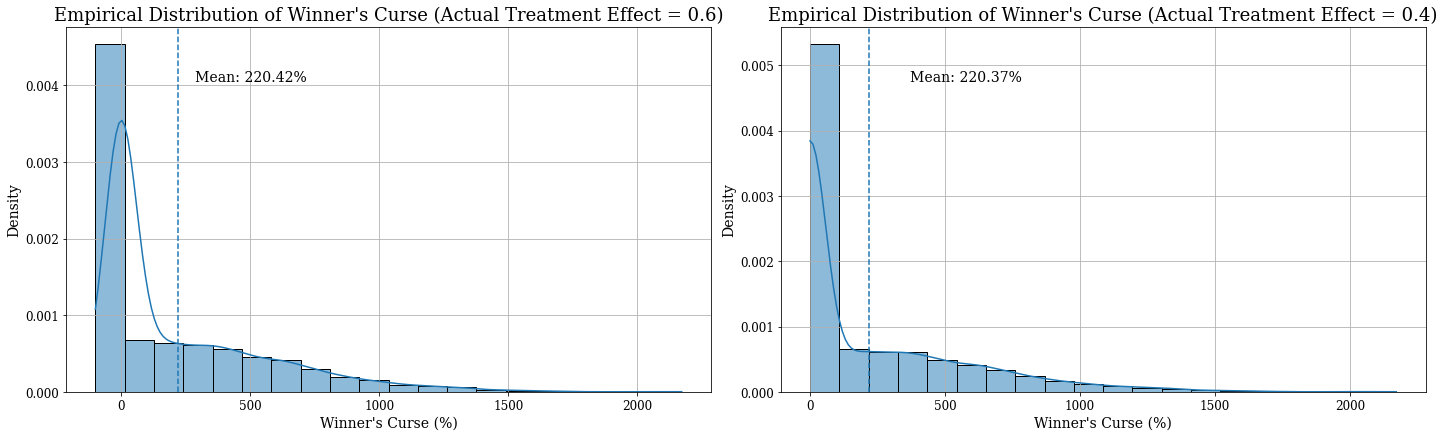

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

sns.histplot(pos_emp_wc_dstn_arr * 100, bins=20, kde=True, stat='density', ax=axes[0], color='C0')
axes[0].axvline(pos_emp_wc_dstn_arr.mean() * 100, color='C0', linestyle='--')
axes[0].annotate(
    f"Mean: {pos_emp_wc_dstn_arr.mean() * 100:.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[0].set_title("Empirical Distribution of Winner's Curse (Actual Treatment Effect = 0.6)", fontsize=title_size)

sns.histplot(neg_emp_wc_dstn_arr * 100, bins=20, kde=True, stat='density', ax=axes[1], color='C0')
axes[1].axvline(neg_emp_wc_dstn_arr.mean() * 100, color='C0', linestyle='--')
axes[1].annotate(
    f"Mean: {neg_emp_wc_dstn_arr.mean() * 100:.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[1].set_title("Empirical Distribution of Winner's Curse (Actual Treatment Effect = 0.4)", fontsize=title_size)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
    ax.set_ylabel('Density', fontsize=axis_label_size)
    ax.grid()

plt.tight_layout()
plt.show()

# Bootstrap Bias Correction

In [119]:
def stratified_bootstrap(
    treatments: np.ndarray, outcomes: np.ndarray, boot_sample_size: int
) -> tuple:
    # stratified bootstrap
    treated_idx = np.where(treatments == 1)[0]
    control_idx = np.where(treatments == 0)[0]

    treated_idx_bootstrap = np.random.choice(treated_idx, size=int(boot_sample_size / 2), replace=True)
    control_idx_bootstrap = np.random.choice(control_idx, size=int(boot_sample_size / 2), replace=True)

    bootstrap_idx = np.concatenate([treated_idx_bootstrap, control_idx_bootstrap])

    return treatments[bootstrap_idx], outcomes[bootstrap_idx]

# Estimating winner's curse

## Standard Bootstrap

In [120]:
def get_wc_boot_dstn(
    treatments: np.ndarray, outcomes: np.ndarray, 
    price: float, cost: float, 
    n_bootstraps: int = 500, **kwargs, 
) -> np.ndarray:
    # attributes
    sample_size = treatments.shape[0]

    # initialize array for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))  # shape = (n_bootstraps)

    # get treatment effect estimate using all data (empirical estimate)
    emp_tau_est = difference_in_mean(treatments=treatments, outcomes=outcomes)
    
    # create bootstrap distribution
    for boot_id in range(n_bootstraps):
        boot_treatment_arr, boot_outcome_arr = stratified_bootstrap(
            treatments=treatments, outcomes=outcomes, boot_sample_size=sample_size
        )

        boot_is_target, boot_target_val_est = plugin_optimize(
            treatments=boot_treatment_arr, outcomes=boot_outcome_arr, 
            price=price, cost=cost, 
        )
        
        # evaluate bootstrap targeting policy using empirical CATE estimates
        emp_target_val_est = obj_func(
            price=price, cost=cost, 
            tau=emp_tau_est, is_target=boot_is_target 
        )

        boot_wc_dstn_arr[boot_id] = boot_target_val_est - emp_target_val_est 

    return boot_wc_dstn_arr

In [121]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.3, 'noise_std': 2}

data_params = {'sample_size': 1000}

experiment_params = {'n_experiments': 5000}

100%|██████████| 5000/5000 [00:00<00:00, 13204.78it/s]


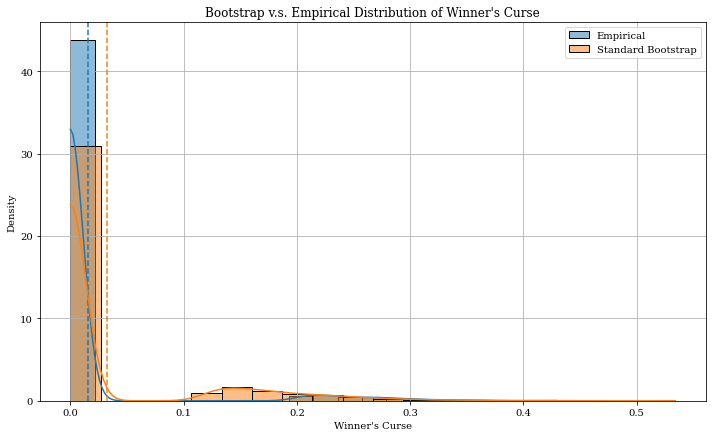

In [122]:
# generate empirical distribution
estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
}
results = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)
emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results])

# generate bootstrap distribution
treatment_arr, outcome_arr = sample(
    **demand_params, sample_size=data_params['sample_size']
)

boot_wc_dstn_arr = get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, 
    **targeting_params, n_bootstraps=5000
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [123]:
def get_wc_m_out_of_n_boot_dstn(
    treatments: np.ndarray, outcomes: np.ndarray, 
    price: float, cost: float, 
    q: float = 0.9, max_j: int = 20, min_m: int = 10, 
    pow: float = 1 / 3, n_bootstraps: int = 500, 
    m_method: str = 'Bickle-Sakov', 
    **kwargs
) -> np.ndarray:
    # attributes
    sample_size = treatments.shape[0]

    # initialize list of arrays for the bootstrap distribution of winner's curse
    m_arr = np.array([int(q**j * sample_size) for j in range(max_j)])
    m_arr = m_arr[m_arr >= min_m]
    # list of numpy arrays with shape (n_bootstraps, )
    m_boot_wc_dstn_list = [np.zeros(shape=(n_bootstraps, ))] * m_arr.shape[0]

    # get treatment effect estimate using all data (empirical estimate)
    emp_tau_est = difference_in_mean(treatments=treatments, outcomes=outcomes)
    
    # create bootstrap distribution
    if m_method == 'Bickle-Sakov':
        for m_id, m in enumerate(m_arr):
            boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))
            for boot_id in range(n_bootstraps):
                boot_treatment_arr, boot_outcome_arr = stratified_bootstrap(
                    treatments=treatments, outcomes=outcomes, boot_sample_size=m
                )

                boot_is_target, boot_target_val_est = plugin_optimize(
                    treatments=boot_treatment_arr, outcomes=boot_outcome_arr, 
                    price=price, cost=cost, 
                )
                
                # evaluate bootstrap targeting policy using empirical CATE estimates
                emp_target_val_est = obj_func(
                    price=price, cost=cost, 
                    tau=emp_tau_est, is_target=boot_is_target 
                )

                boot_wc_dstn_arr[boot_id] = boot_target_val_est - emp_target_val_est 

            m_boot_wc_dstn_list[m_id] = boot_wc_dstn_arr

        return choose_best_m(m_boot_wc_dstn_list)

    elif m_method == 'power':
        m = int(sample_size ** pow)
        boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))
        for boot_id in range(n_bootstraps):
                boot_treatment_arr, boot_outcome_arr = stratified_bootstrap(
                    treatments=treatments, outcomes=outcomes, boot_sample_size=m
                )

                boot_is_target, boot_target_val_est = plugin_optimize(
                    treatments=boot_treatment_arr, outcomes=boot_outcome_arr, 
                    price=price, cost=cost, 
                )
                
                # evaluate bootstrap targeting policy using empirical CATE estimates
                emp_target_val_est = obj_func(
                    price=price, cost=cost, 
                    tau=emp_tau_est, is_target=boot_is_target 
                )

                boot_wc_dstn_arr[boot_id] = boot_target_val_est - emp_target_val_est 


        return boot_wc_dstn_arr
    else:
        raise ValueError(f'Invalid m_method: {m_method}')

In [124]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.3, 'noise_std': 2}

data_params = {'sample_size': 50}

experiment_params = {'n_experiments': 5000}

100%|██████████| 5000/5000 [00:00<00:00, 45292.22it/s]


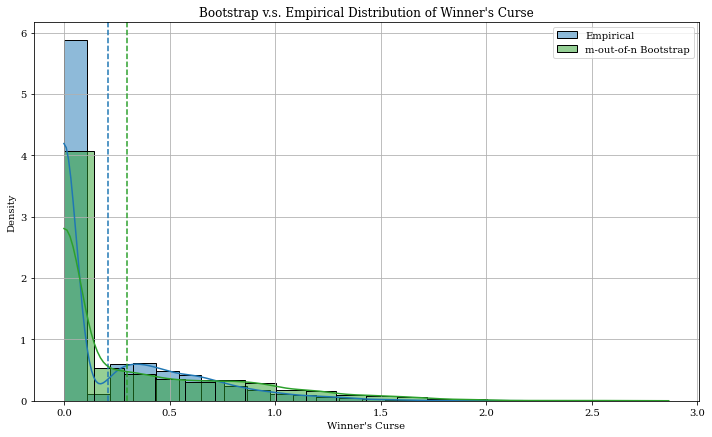

In [125]:
# generate empirical distribution
estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
}
results = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)
emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results])

# generate bootstrap distribution
treatment_arr, outcome_arr = sample(
    **demand_params, sample_size=data_params['sample_size']
)

mnb_wc_dstn_arr = get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, 
    m_method='power', pow=5/6, 
    # m_method='Bickle-Sakov', q=0.95, max_j=20, min_m=10,
    **targeting_params, n_bootstraps=5000
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(mnb_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mnb_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## (Fang and Santos 2019)

Differentiate $WC(\hat{\tau})$ w.r.t. $\hat{\tau}$ in direction $h$, we have:
$$
WC'_{\tau}(h)  = \begin{cases}
ph, \quad & \text{if } \tau > c / p \\ 
\max\{ph - c, 0\}, \quad & \text{if } \tau = c / p \\ 
0, \quad & \text{if } \tau < c / p \\ 
\end{cases}
$$

An estimator for the winner's curse would be: 
$$
\hat{WC}'_{\hat{\tau}}(h)  = \begin{cases}
ph, \quad & \text{if } \sqrt{n}(\hat{\tau} - c/p) / \hat{\sigma} > \kappa_n \\ 
\max\{ph - c, 0\}, \quad & \text{if } \sqrt{n}(\hat{\tau} - c/p) / \hat{\sigma} = \kappa_n \\ 
0, \quad & \text{if } \sqrt{n}(\hat{\tau} - c/p) / \hat{\sigma} < \kappa_n \\ 
\end{cases}
$$

In [126]:
def get_wc_fs_boot_dstn(
    treatments: np.ndarray, outcomes: np.ndarray,
    price: float, cost: float,
    n_bootstraps: int = 500, **kwargs,
) -> np.ndarray:
   """ 
   TODO
   """

   raise NotImplementedError

## Numerical Bootstrap

In [127]:
def get_wc_num_boot_dstn(
    treatments: np.ndarray, outcomes: np.ndarray,
    price: float, cost: float,
    n_bootstraps: int = 500, pow: int = -0.25, 
    ep_bootstrap: 'str' = 'standard', 
    **kwargs,
) -> np.ndarray:
    # attributes
    assert 0 > pow > -0.5, "Power must be between 0 and -0.5"
    sample_size = treatments.shape[0]

    # get treatment effect estimate using all data (empirical estimate)
    emp_tau_est = difference_in_mean(treatments=treatments, outcomes=outcomes)

    # create bootstrap samples
    boot_tau_est_arr = np.zeros(shape=(n_bootstraps, ))

    for i in range(n_bootstraps):
        # stratified bootstrap
        boot_treatment_arr, boot_outcome_arr = stratified_bootstrap(
            treatments=treatments, outcomes=outcomes, boot_sample_size=sample_size
        )
        # estimate treatment effect with difference in mean estimator
        boot_tau_est_arr[i] = difference_in_mean(
            treatments=boot_treatment_arr, outcomes=boot_outcome_arr
        )

    if ep_bootstrap == 'standard':
        boot_tau_err_arr = np.sqrt(sample_size) * (boot_tau_est_arr - emp_tau_est)
        # print(boot_tau_err_arr.mean(), boot_tau_err_arr.std())
    elif ep_bootstrap == 'parametric':
        boot_tau_err_arr = UnivariateGaussian(
            mean=0, std=np.std(boot_tau_est_arr - emp_tau_est, ddof=1)
        ).sample(n_bootstraps)
        print(boot_tau_err_arr.mean(), boot_tau_err_arr.std())
    else:
        raise ValueError(f"Invalid bootstrap method: {ep_bootstrap}")
    return price * (sample_size ** pow) * boot_tau_err_arr * (price * boot_tau_est_arr > cost)

100%|██████████| 5000/5000 [00:00<00:00, 12830.02it/s]


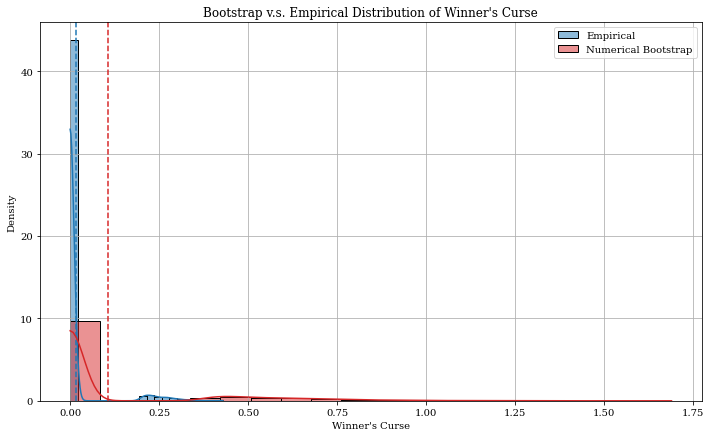

In [128]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.3, 'noise_std': 2}

data_params = {'sample_size': 1000}

experiment_params = {'n_experiments': 5000}

# generate empirical distribution
estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
}
results = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)
emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results])

# generate bootstrap distribution
treatment_arr, outcome_arr = sample(
    **demand_params, sample_size=data_params['sample_size']
)

numb_wc_dstn_arr = get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, 
    **targeting_params, n_bootstraps=10000, pow=-1/3, 
    ep_bootstrap='standard'
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(numb_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(numb_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [129]:
def bootstrap_correction_estimate(
    treatments: np.ndarray, outcomes: np.ndarray, 
    price: float, cost: float, 
    bootstrap_method: str = 'standard', **kwargs, 
) -> np.ndarray:
    # solve plugin problem
    _, plugin_target_val_est = plugin_optimize(
        treatments=treatments, outcomes=outcomes, 
        price=price, cost=cost, 
    )

    # dictionary of available bootstrap methods
    boot_methods_dict = {
        'standard': get_wc_boot_dstn, 
        'm_out_of_n': get_wc_m_out_of_n_boot_dstn, 
        'numerical': get_wc_num_boot_dstn, 
    }

    # get the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = boot_methods_dict[bootstrap_method](
        treatments=treatments, outcomes=outcomes, 
        price=price, cost=cost, **kwargs, 
    )

    return plugin_target_val_est - boot_wc_dstn_arr.mean()

# Sensitivity Analysis

## Number of bootstraps

In [227]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.1, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': np.nan, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': np.nan, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': 0.95
        }
    }, 
    'numb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': np.nan, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': - 0.45
        }
    }
}

In [228]:
num_bootstraps_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 5000]
result_dict = {num_bootstraps: None for num_bootstraps in num_bootstraps_list}

for idx, num_bootstraps in enumerate(num_bootstraps_list):
    estimators_dict['bootstrap_correction']['params']['n_bootstraps'] = num_bootstraps
    estimators_dict['mnb_correction']['params']['n_bootstraps'] = num_bootstraps
    estimators_dict['numb_correction']['params']['n_bootstraps'] = num_bootstraps

    results = repeated_experiments(
        targeting_params=targeting_params, 
        demand_params=demand_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in results]) 
        for name in estimators_dict.keys()
    })

    result_dict[num_bootstraps] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[num_bootstraps].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case1_num_bootstraps_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

100%|██████████| 1000/1000 [06:03<00:00,  2.75it/s]


In [230]:
with open('results/case1_num_bootstraps_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T
result_df

,plugin_mean,bootstrap_correction_mean,mnb_correction_mean,numb_correction_mean,plugin_se,bootstrap_correction_se,mnb_correction_se,numb_correction_se
100,0.241918,0.059823,0.020092,0.007141,0.030282,0.030719,0.030648,0.031083
200,0.241918,0.059694,0.017527,0.004214,0.030282,0.030630,0.030541,0.031018
300,0.241918,0.060569,0.018605,0.004002,0.030282,0.030678,0.030634,0.030822
400,0.241918,0.060518,0.017223,0.005655,0.030282,0.030635,0.030496,0.030969
500,0.241918,0.060539,0.017066,0.005824,0.030282,0.030654,0.030537,0.031021
600,0.241918,0.060226,0.016708,0.005873,0.030282,0.030598,0.030565,0.030976
700,0.241918,0.060011,0.017104,0.005496,0.030282,0.030585,0.030547,0.031005
800,0.241918,0.059974,0.017499,0.005579,0.030282,0.030587,0.030566,0.030951
900,0.241918,0.060151,0.016734,0.005658,0.030282,0.030589,0.030509,0.030943
1000,0.241918,0.060126,0.017441,0.005551,0.030282,0.030606,0.030548,0.030887


## Hyperparameter

### m-out-of-n

In [27]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': np.nan, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': np.nan
        }
    }, 
}

In [28]:
tau_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(tau, power): None for tau in tau_list for power in power_list}

for tau in tau_list:
    demand_params['tau'] = tau
    for power in power_list: 
        print(f'Tau = {tau}, Power = {power}')
        estimators_dict['mnb_correction']['params']['pow'] = power
        
        result_record = repeated_experiments(
            targeting_params=targeting_params, 
            demand_params=demand_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in estimators_dict.keys()
        })

        result_dict[(tau, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

Tau = -0.2, Power = 0.88


100%|██████████| 1000/1000 [00:49<00:00, 20.28it/s]


Tau = -0.2, Power = 0.9


100%|██████████| 1000/1000 [00:49<00:00, 20.23it/s]


Tau = -0.2, Power = 0.92


...

100%|██████████| 1000/1000 [00:53<00:00, 18.84it/s]


Tau = 1, Power = 0.95


100%|██████████| 1000/1000 [00:54<00:00, 18.23it/s]


Tau = 1, Power = 0.97


100%|██████████| 1000/1000 [00:51<00:00, 19.25it/s]


In [60]:
with open('results/case1_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'bootstrap_correction_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mnb_correction_mean']]
    best_wc_list[idx] = temp['mnb_correction_mean'].loc[(-temp['mnb_correction_mean'].abs()).idxmax()]

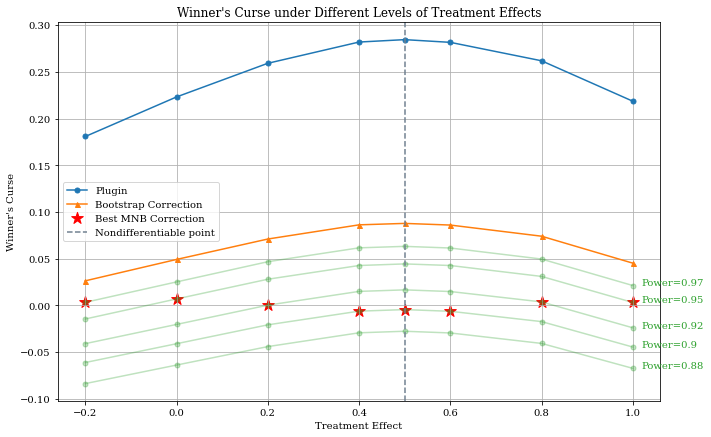

In [61]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['bootstrap_correction_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mnb_correction_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mnb_correction_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['mnb_correction_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best MNB Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects")
ax.set_xlabel('Treatment Effect')
ax.set_ylabel("Winner's Curse")

ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

### Numerical bootstrap

In [140]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': np.nan, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'numb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': np.nan
        }
    }, 
}

In [141]:
tau_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [-0.35, -0.40, -0.45, -0.49]
result_dict = {(tau, power): None for tau in tau_list for power in power_list}

for tau in tau_list:
    demand_params['tau'] = tau
    for power in power_list: 
        print(f'Tau = {tau}, Power = {power}')
        estimators_dict['numb_correction']['params']['pow'] = power
        
        result_record = repeated_experiments(
            targeting_params=targeting_params, 
            demand_params=demand_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in estimators_dict.keys()
        })

        result_dict[(tau, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

Tau = -0.2, Power = -0.35


100%|██████████| 1000/1000 [00:48<00:00, 20.43it/s]


Tau = -0.2, Power = -0.4


100%|██████████| 1000/1000 [00:49<00:00, 20.26it/s]


Tau = -0.2, Power = -0.45


...

100%|██████████| 1000/1000 [00:47<00:00, 20.91it/s]


Tau = 1, Power = -0.45


100%|██████████| 1000/1000 [00:47<00:00, 21.17it/s]


Tau = 1, Power = -0.49


100%|██████████| 1000/1000 [00:47<00:00, 21.17it/s]


In [244]:
with open('results/case1_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'bootstrap_correction_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'numb_correction_mean']]
    best_wc_list[idx] = temp['numb_correction_mean'].loc[(-temp['numb_correction_mean'].abs()).idxmax()]

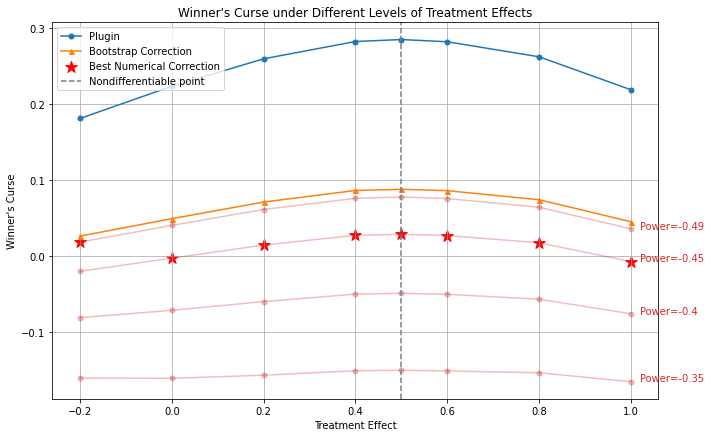

In [247]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['bootstrap_correction_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'numb_correction_mean']]
    ax.plot(mnb_df['tau'], mnb_df['numb_correction_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['numb_correction_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Numerical Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects")
ax.set_xlabel('Treatment Effect')
ax.set_ylabel("Winner's Curse")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Sample Size

In [131]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.6, 'noise_std': 5}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': 0.9
        }
    }, 
    'numb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': - 0.45
        }
    }
}

In [237]:
sample_size_list = [50, 100, 200, 300, 400, 500, 750, 1000]
result_dict = {sample_size: None for sample_size in sample_size_list}

for idx, sample_size in enumerate(sample_size_list):
    data_params['sample_size'] = sample_size

    results = repeated_experiments(
        targeting_params=targeting_params, 
        demand_params=demand_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in results]) 
        for name in estimators_dict.keys()
    })

    result_dict[sample_size] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[sample_size].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case1_sample_size_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

100%|██████████| 1000/1000 [05:56<00:00,  2.81it/s]


In [251]:
with open('results/case1_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T
result_df

,plugin_mean,bootstrap_correction_mean,mnb_correction_mean,numb_correction_mean,plugin_se,bootstrap_correction_se,mnb_correction_se,numb_correction_se
50,0.593501,0.210346,0.060143,0.126174,0.117969,0.131230,0.131670,0.133902
100,0.404877,0.133824,0.018801,0.062988,0.057792,0.063843,0.063955,0.065469
200,0.284563,0.087822,-0.005082,0.028948,0.029349,0.032670,0.032722,0.033738
300,0.225645,0.062555,-0.021503,0.007483,0.018475,0.020512,0.020503,0.021227
400,0.218077,0.078034,0.001055,0.028371,0.014832,0.016469,0.016522,0.017121
500,0.172781,0.047038,-0.023390,0.000633,0.011906,0.013197,0.013286,0.013746
750,0.146422,0.041403,-0.020175,0.000472,0.007669,0.008512,0.008555,0.008897
1000,0.133442,0.042902,-0.013267,0.006017,0.005912,0.006586,0.006601,0.006886


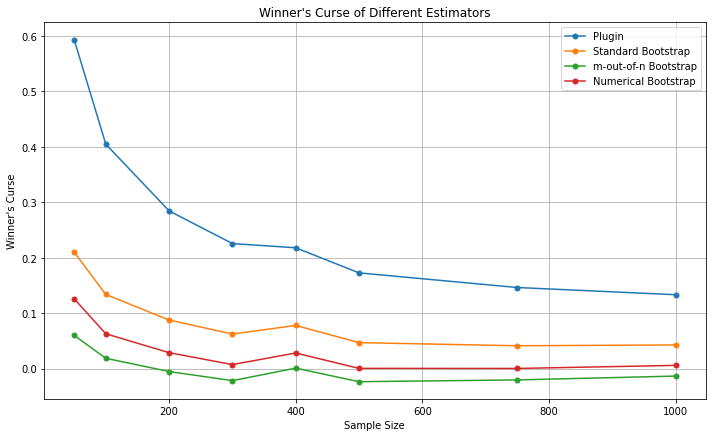

In [256]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')
# ax.fill_between(
#     result_df.index, 
#     result_df['plugin_mean'] - 1.96 * result_df['plugin_se'], 
#     result_df['plugin_mean'] + 1.96 * result_df['plugin_se'], 
#     color='C0', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['plugin_mean'], yerr= 1.96 * result_df['plugin_se'], 
#     fmt='o', capsize=5, label='Plugin', color='C0'
# )

# standard bootstrap 
ax.plot(result_df.index, result_df['bootstrap_correction_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
# ax.fill_between(
#     result_df.index, 
#     result_df['bootstrap_correction_mean'] - 1.96 * result_df['bootstrap_correction_se'], 
#     result_df['bootstrap_correction_mean'] + 1.96 * result_df['bootstrap_correction_se'], 
#     color='C1', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['bootstrap_correction_mean'], yerr= 1.96 * result_df['bootstrap_correction_se'],
#     fmt='o', capsize=5, label='Standard Bootstrap', color='C1'
# )

# m out of n bootstrap
ax.plot(result_df.index, result_df['mnb_correction_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
# ax.fill_between(
#     result_df.index, 
#     result_df['mnb_correction_mean'] - 1.96 * result_df['mnb_correction_se'], 
#     result_df['mnb_correction_mean'] + 1.96 * result_df['mnb_correction_se'], 
#     color='C2', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['mnb_correction_mean'], yerr= 1.96 * result_df['mnb_correction_se'],
#     fmt='o', capsize=5, label='m-out-of-n Bootstrap', color='C2'
# )

# numerical bootstrap
ax.plot(result_df.index, result_df['numb_correction_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
# ax.fill_between(
#     result_df.index, 
#     result_df['numb_correction_mean'] - 1.96 * result_df['numb_correction_se'], 
#     result_df['numb_correction_mean'] + 1.96 * result_df['numb_correction_se'], 
#     color='C3', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['numb_correction_mean'], yerr= 1.96 * result_df['numb_correction_se'],
#     fmt='o', capsize=5, label='Numerical Bootstrap', color='C3'
# )

ax.set_title("Winner's Curse of Different Estimators")
ax.set_xlabel('Sample Size')
ax.set_ylabel("Winner's Curse")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()